# 1.3. 선 스펙트럼과 Bohr의 원자 모형

In [1]:
import numpy as np

B = 364.56
n = np.arange(3, 8)
lam = B * n**2 / (n**2 - 4)

obs = np.array([656.279, 486.135, 434.0472, 410.1734, 397.0075])

for ni, l, o in zip(n, lam, obs):
    print(
        f"n={ni}   Balmer 공식 {l:7.2f} nm   관측값 {o:7.2f} nm   차이 {abs(l-o):.2f} nm"
    )

n=3   Balmer 공식  656.21 nm   관측값  656.28 nm   차이 0.07 nm
n=4   Balmer 공식  486.08 nm   관측값  486.13 nm   차이 0.06 nm
n=5   Balmer 공식  434.00 nm   관측값  434.05 nm   차이 0.05 nm
n=6   Balmer 공식  410.13 nm   관측값  410.17 nm   차이 0.04 nm
n=7   Balmer 공식  396.97 nm   관측값  397.01 nm   차이 0.04 nm


In [2]:
x = 1 / 4 - 1 / n**2
y = 1 / (obs * 1e-9)

slope, intercept = np.polyfit(x, y, 1)
print(f"관측값에서 얻은 R = {slope:.6e} m^-1")
print(f"문헌값         R = 1.097373e+07 m^-1")

관측값에서 얻은 R = 1.097102e+07 m^-1
문헌값         R = 1.097373e+07 m^-1


In [3]:
from scipy.constants import c, e, m_e, epsilon_0

r0 = 1e-10

t_collapse = m_e**2 * c**3 * (4 * np.pi * epsilon_0) ** 2 / (4 * e**4) * (r0**3)

print(f"붕괴 시간 = {t_collapse:.3e} 초")

붕괴 시간 = 1.050e-10 초


In [4]:
from scipy.constants import h

R_bohr = m_e * e**4 / (8 * epsilon_0**2 * h**3 * c)

print(f"Bohr 모형에서 계산한 R = {R_bohr:.6e} m^-1")
print(f"문헌값              R = 1.097373e+07 m^-1")

Bohr 모형에서 계산한 R = 1.097373e+07 m^-1
문헌값              R = 1.097373e+07 m^-1


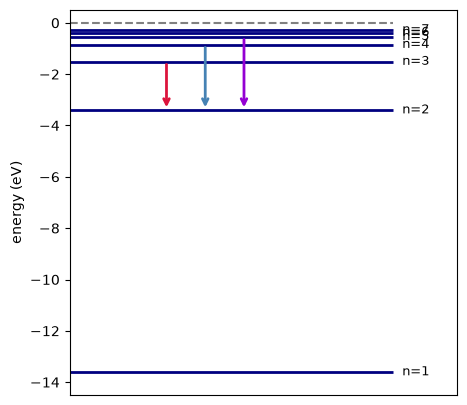

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))

for ni in range(1, 8):
    E = -13.606 / ni**2
    ax.hlines(E, 0, 1, lw=2, color="navy")
    ax.text(1.03, E, f"n={ni}", va="center", fontsize=9)

ax.hlines(0, 0, 1, lw=1.5, ls="--", color="gray")

# Balmer 계열: n = 3, 4, 5에서 n = 2로
for ni, col in zip([3, 4, 5], ["crimson", "steelblue", "darkviolet"]):
    xpos = 0.3 + 0.12 * (ni - 3)
    ax.annotate(
        "",
        xy=(xpos, -13.606 / 4),
        xytext=(xpos, -13.606 / ni**2),
        arrowprops=dict(arrowstyle="->", color=col, lw=2),
    )

ax.set_xlim(0, 1.2)
ax.set_ylim(-14.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("energy (eV)")
plt.show()